In [37]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Navigate two directories up from the current directory
module_path = os.path.abspath(os.path.join(current_dir, '..', '..'))

# Add this path to sys.path
if module_path not in sys.path:
    sys.path.append(module_path)

In [38]:
from h5cloud.test_config import TestConfig
from h5cloud.tests.h5py_arr_mean import H5pyArrMean
from h5cloud.tests.h5coro_arr_mean import H5CoroArrMean
from h5cloud.tests.xarray_arr_mean import XarrayArrMean
import matplotlib.pyplot as plt

In [39]:
tc = TestConfig.load_from_yaml(
    yaml_file="../../h5cloud/file_configs/SNDRSNIML2CCPRETN_2.yaml",
    results_bucket="nasa-veda-scratch",
    results_directory="h5cloud-results"
)
results = {}

In [40]:
fsspec_params = {
    # "skip_instance_cache": True
    "cache_type": "blockcache",  # or "first" with enough space
    "block_size": 8*1024*1024 # could be bigger
}
driver_kwds = { # only recent versions of xarray and h5netcdf allow this correctly
    "page_buf_size": 32*1024*1024, # this one only works in repacked files
    "rdcc_nbytes": 8*1024*1024 # this one is to read the chunks 
}
io_params = {
    "fsspec_params": fsspec_params,
    "h5py_params": { "driver_kwds": driver_kwds }
}

# H5Py Array Mean

In [41]:
h5py_arr_test = H5pyArrMean(tc, store_results=False)
results['h5py_arr_test'] = {}

In [42]:
for file_format, file in tc.files.items():
    # run test on file
    if 'kerchunk' not in file_format:
        results['h5py_arr_test'][file_format] = h5py_arr_test.run(file_format)
        results['h5py_arr_test'][f"{file_format}_wparams"] = h5py_arr_test.run(file_format=file_format, io_params=io_params)
    

# H5Coro Array Mean

In [43]:
h5coro_arr_test = H5CoroArrMean(tc, store_results=False)
results['h5coro_arr_test'] = {}

In [44]:
for file_format, file in tc.files.items():
    # run test on file
    if 'kerchunk' not in file_format:
        results['h5coro_arr_test'][file_format] = h5coro_arr_test.run(file_format)
    

# Xarray Array Mean

Note: it does seem like the first time tests are run a cache is created, despite efforts to pass cache=False and ds.close().

In [45]:
xr_arr_test = XarrayArrMean(tc, store_results=False)
results['xr_arr_test'] = {}

In [46]:
for file_format, file in tc.files.items():
    results['xr_arr_test'][file_format] = xr_arr_test.run(file_format)
    if file_format != 'original':
        results['xr_arr_test'][f"{file_format}_wparams"] = xr_arr_test.run(file_format=file_format, io_params=io_params)

In [47]:
results['xr_arr_test'] 

{'kerchunk': (254.5687713623047, 0.615347146987915),
 'kerchunk_wparams': (254.5687713623047, 0.478543758392334),
 'kerchunk_repacked_page_4mb': (254.5687713623047, 0.7147064208984375),
 'kerchunk_repacked_page_4mb_wparams': (254.5687713623047, 0.576711893081665),
 'original': (254.5687713623047, 1.1119279861450195),
 'repacked_page_4mb': (254.5687713623047, 7.316617488861084),
 'repacked_page_4mb_wparams': (254.5687713623047, 1.3438646793365479)}

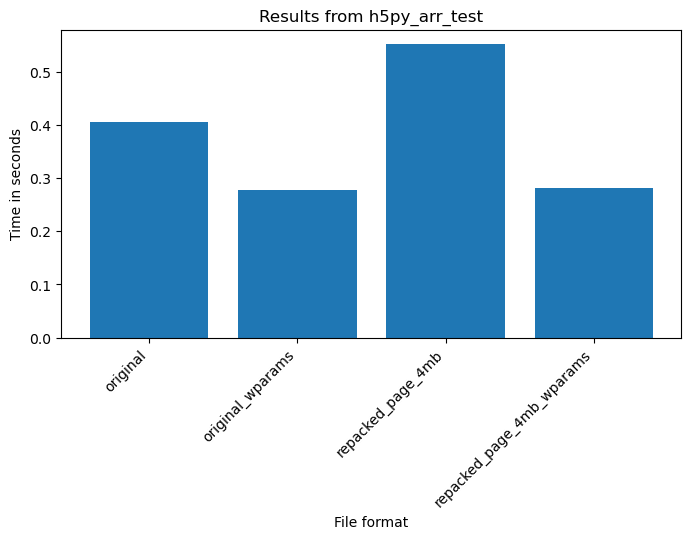

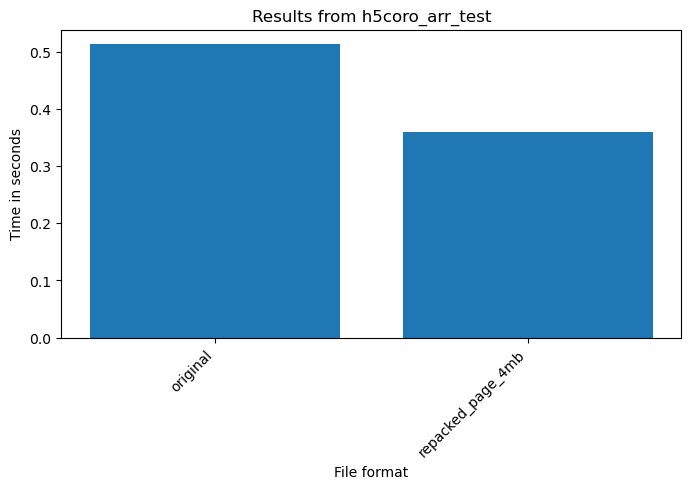

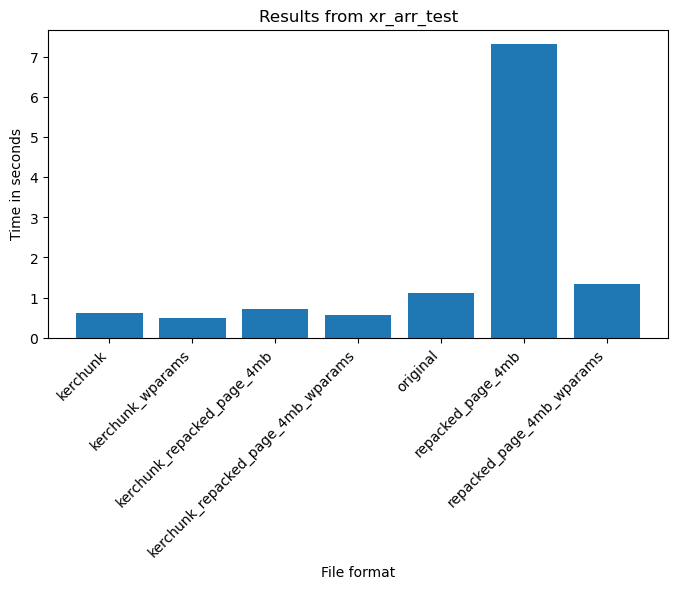

In [48]:
for test, test_results in results.items():
    # Extracting keys and the second element of each tuple
    formats = list(test_results.keys())
    times = [value[1] for value in test_results.values()]
    
    # Creating the bar plot
    plt.figure(figsize=(8, 4))  # Optional: Adjust the figure size
    plt.bar(formats, times)  # You can customize the color
    plt.xlabel('File format')
    plt.ylabel('Time in seconds')
    plt.title(f"Results from {test}")
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')  # Rotates labels to 45 degrees
    #ax.set_xticklabels(group_labels, ha='right')
    
    plt.show()    